# Comparing methods of hurricane forecast uncertainty
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria

In [1]:
import datetime
import os
import pickle
import pprint
import time

import experiment_settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from build_data import build_hurricane_data
import build_model
from model_diagnostics import plot_history
from save_model_run import save_model_run
from sklearn import preprocessing
from training_instrumentation import TrainingInstrumentation
from silence_tensorflow import silence_tensorflow
import tensorflow_probability as tfp
import random
import imp

silence_tensorflow()

tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "v1.0.1, 27 July 2022"

imp.reload(experiment_settings)
EXP_NAME_LIST = (
    "longitude501_EPCP24",
    "latitude501_EPCP24",
    "longitude504_EPCP96",
    "latitude504_EPCP96",
    "longitude401_AL24",
    "latitude401_AL24",

)

OVERWRITE_MODEL = False
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

## Start looping through runs

'latitude501_EPCP24_2021_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 913.
Epoch 01163: early stopping
{'best_epoch': 912,
 'elapsed_time': 29.968780040740967,
 'loss_train': 5.193465232849121,
 'loss_valid': 5.157618522644043,
 'network_seed': 234}


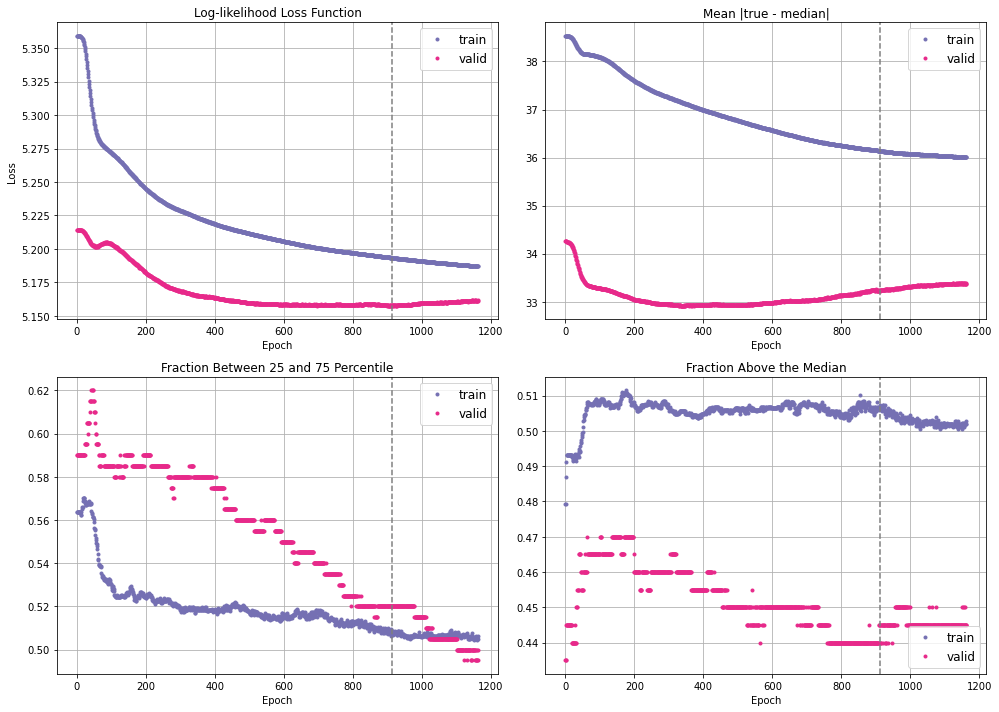

'latitude501_EPCP24_2021_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 77.
Epoch 00327: early stopping
{'best_epoch': 76,
 'elapsed_time': 8.73723316192627,
 'loss_train': 5.268426895141602,
 'loss_valid': 5.1952924728393555,
 'network_seed': 345}


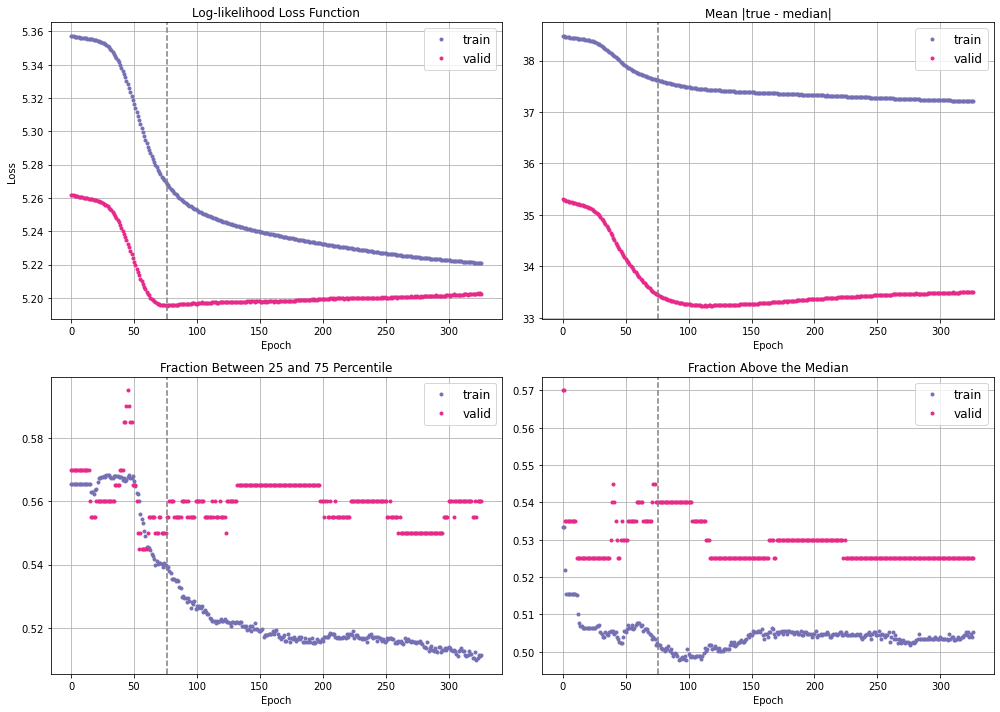

'longitude504_EPCP96_2013_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 1218.
Epoch 01468: early stopping
{'best_epoch': 1217,
 'elapsed_time': 22.008185863494873,
 'loss_train': 6.316537380218506,
 'loss_valid': 6.4248785972595215,
 'network_seed': 123}


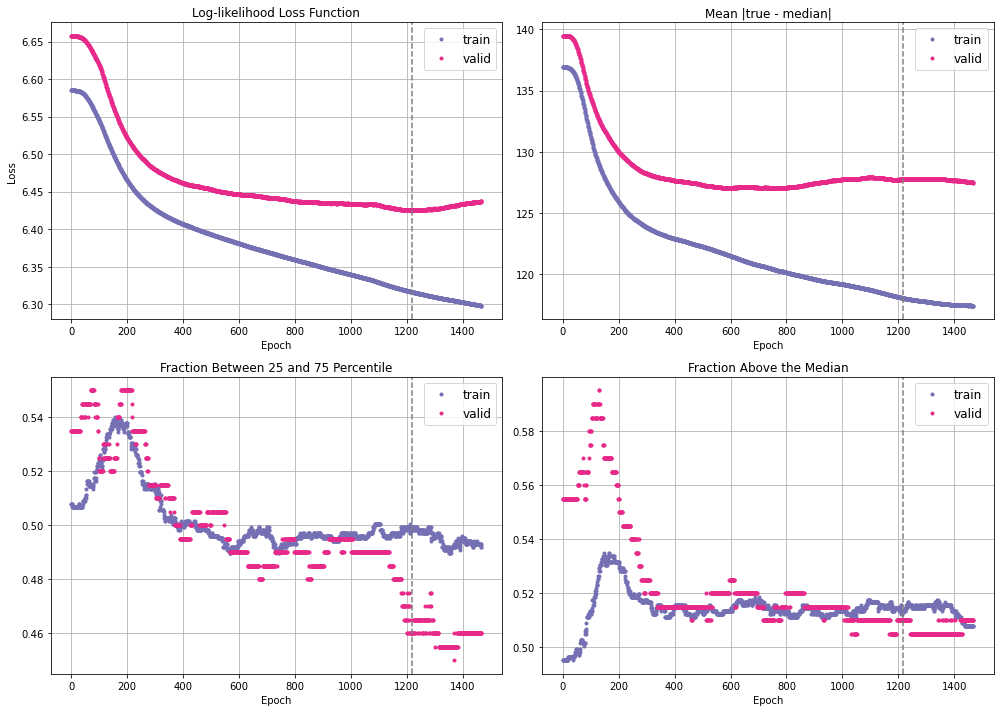

'longitude504_EPCP96_2013_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 2013.
Epoch 02263: early stopping
{'best_epoch': 2012,
 'elapsed_time': 33.684818983078,
 'loss_train': 6.284090995788574,
 'loss_valid': 6.3618950843811035,
 'network_seed': 234}


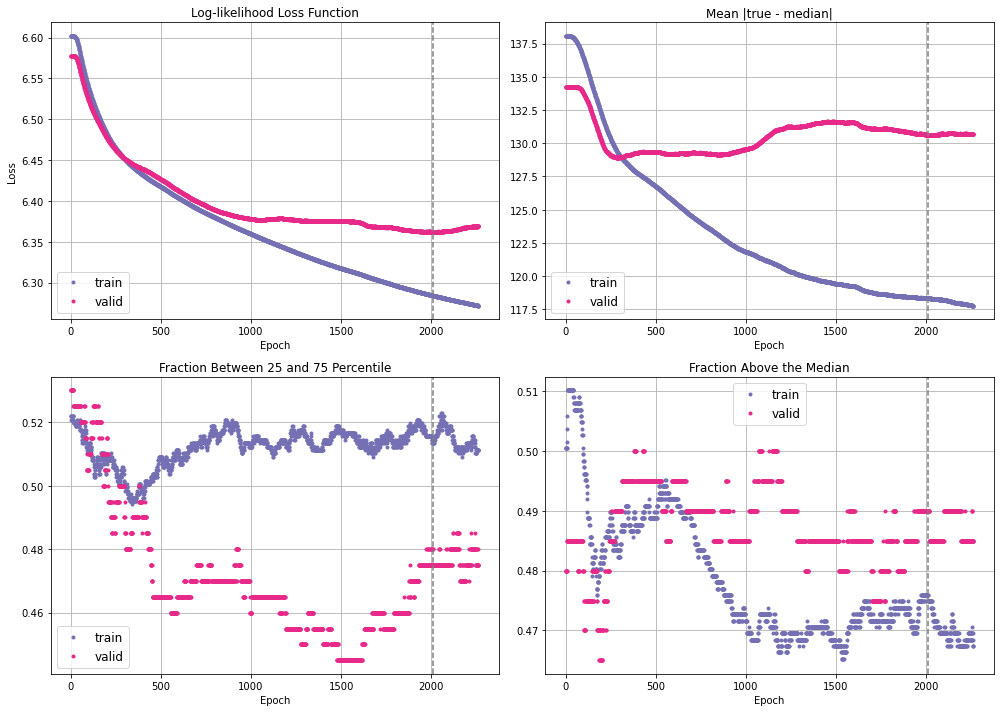

'longitude504_EPCP96_2013_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 439.
Epoch 00689: early stopping
{'best_epoch': 438,
 'elapsed_time': 10.553443908691406,
 'loss_train': 6.401343822479248,
 'loss_valid': 6.414467811584473,
 'network_seed': 345}


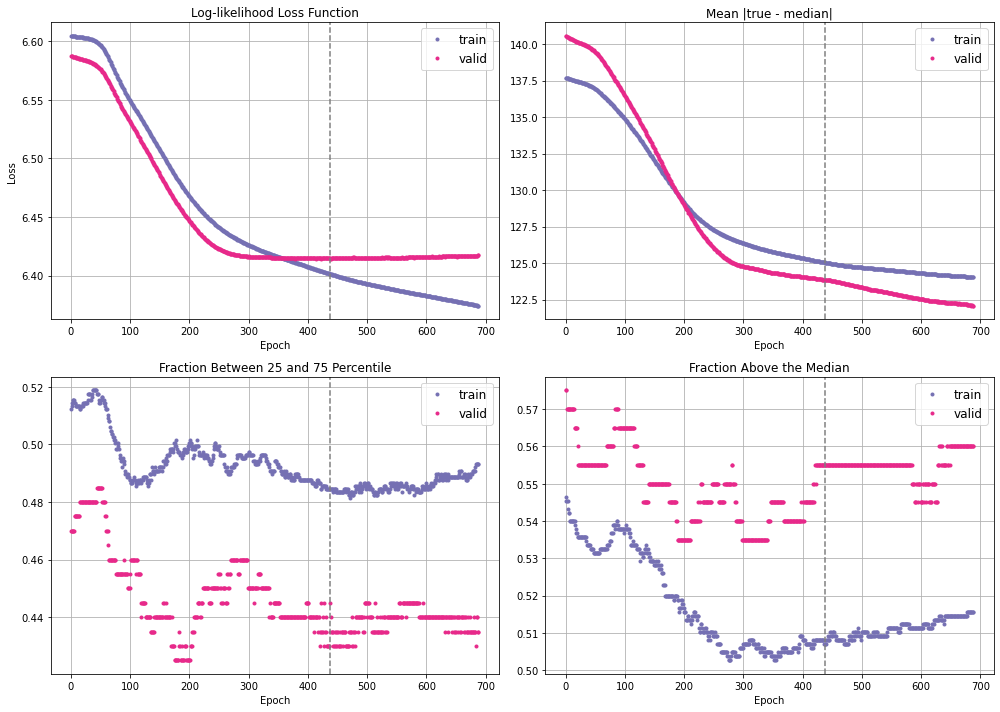

'longitude504_EPCP96_2014_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 458.
Epoch 00708: early stopping
{'best_epoch': 457,
 'elapsed_time': 10.62486481666565,
 'loss_train': 6.385842323303223,
 'loss_valid': 6.5335612297058105,
 'network_seed': 123}


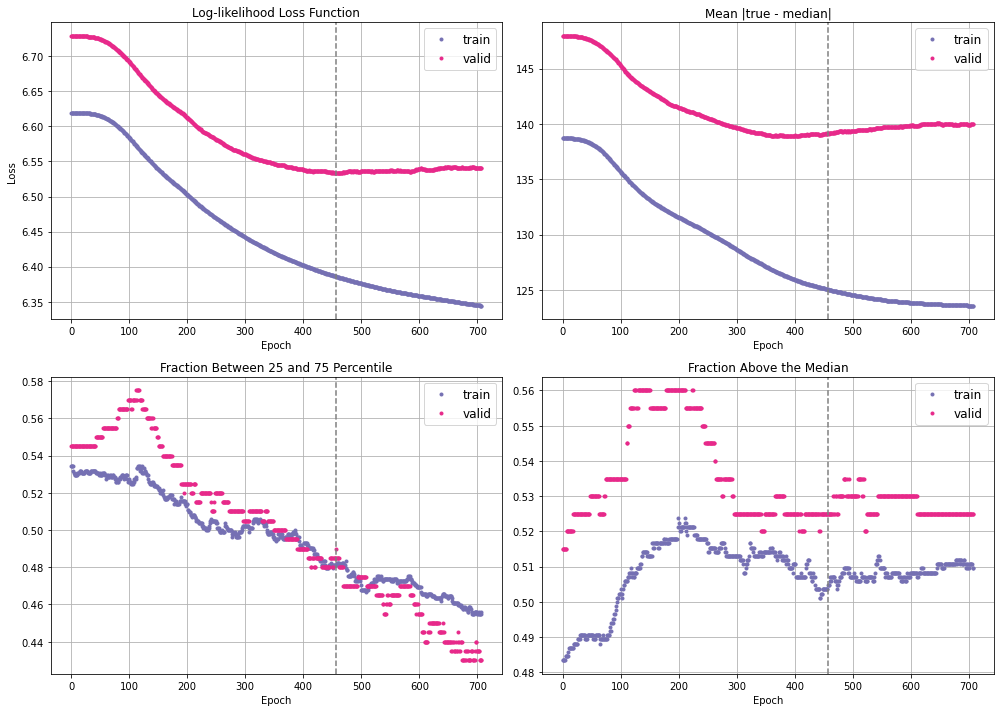

'longitude504_EPCP96_2014_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 1674.
Epoch 01924: early stopping
{'best_epoch': 1673,
 'elapsed_time': 27.62951683998108,
 'loss_train': 6.330278396606445,
 'loss_valid': 6.434212684631348,
 'network_seed': 234}


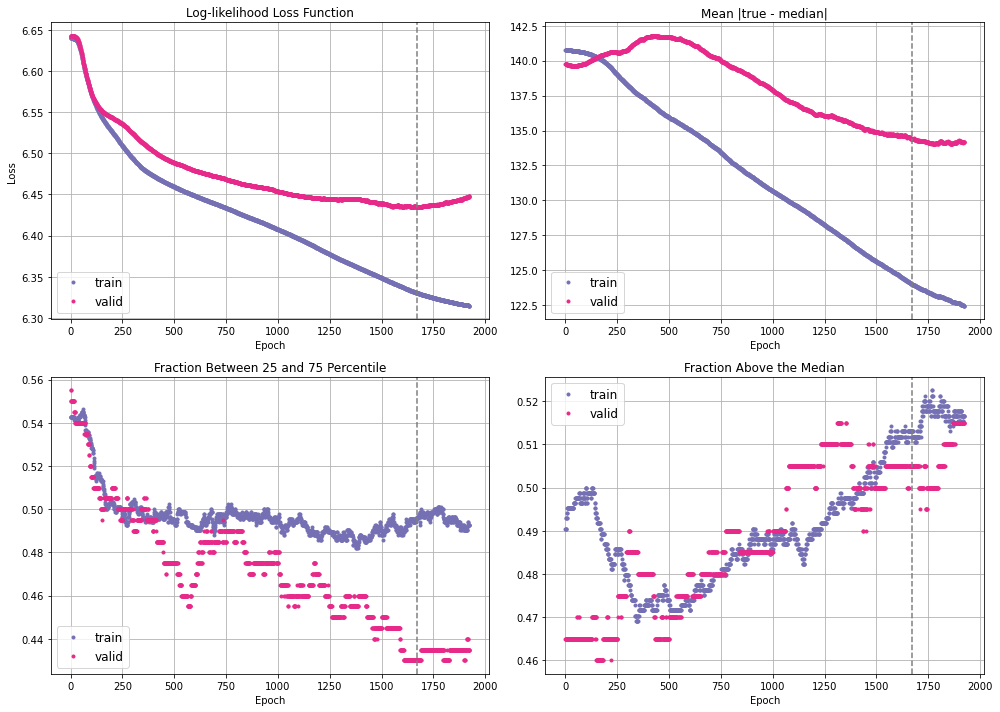

'longitude504_EPCP96_2014_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 1449.
Epoch 01699: early stopping
{'best_epoch': 1448,
 'elapsed_time': 25.339635133743286,
 'loss_train': 6.386025905609131,
 'loss_valid': 6.452087879180908,
 'network_seed': 345}


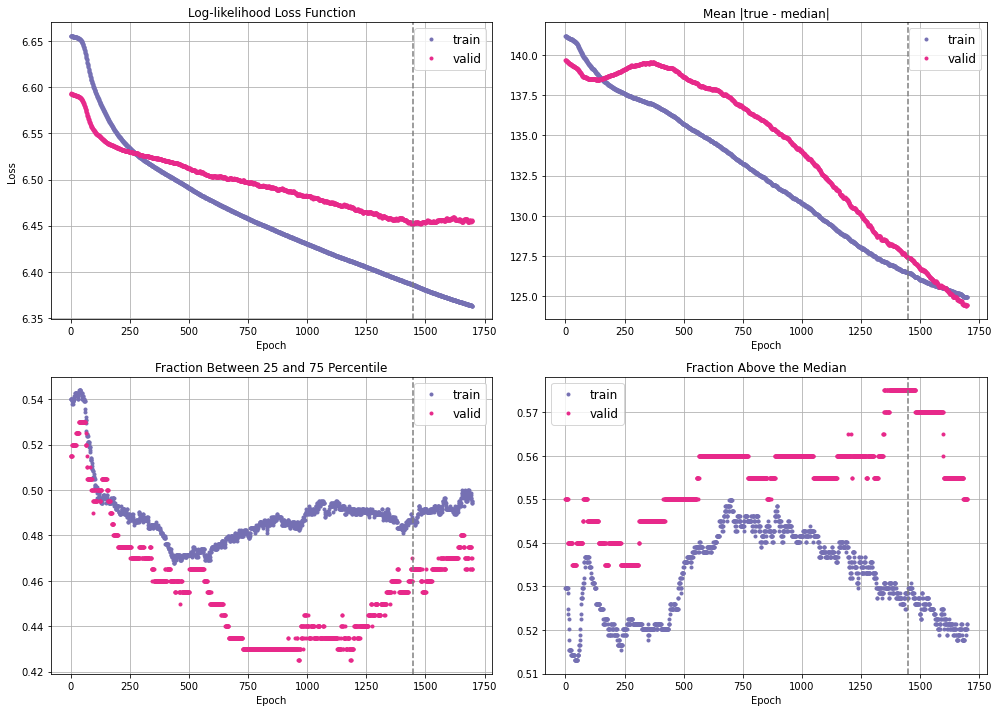

'longitude504_EPCP96_2015_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 431.
Epoch 00681: early stopping
{'best_epoch': 430,
 'elapsed_time': 9.760378122329712,
 'loss_train': 6.459018707275391,
 'loss_valid': 6.572412014007568,
 'network_seed': 123}


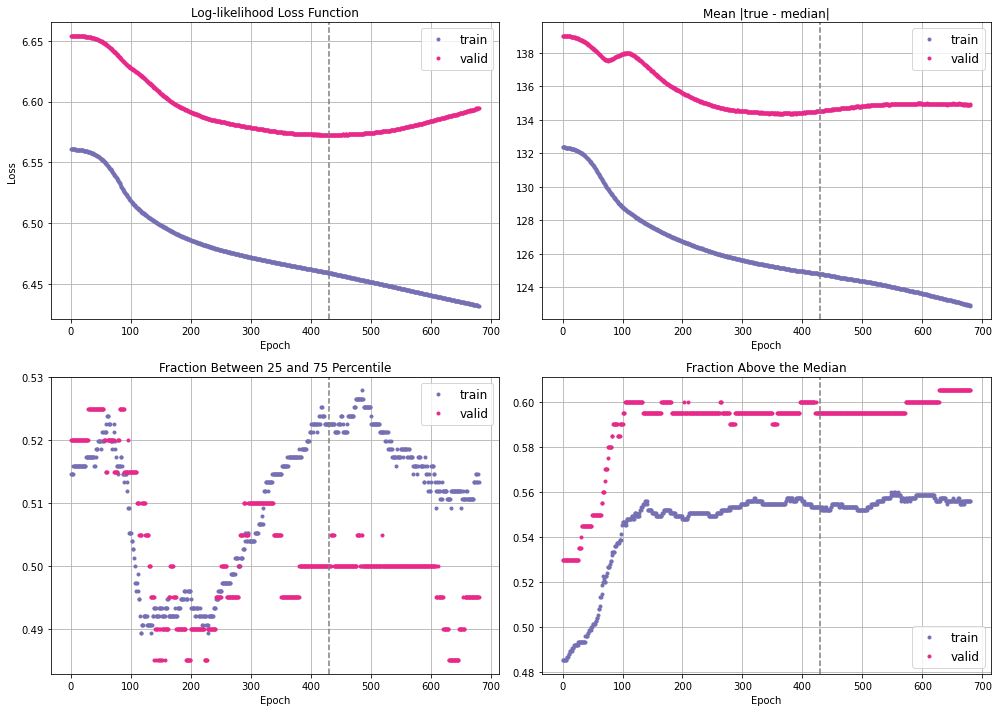

'longitude504_EPCP96_2015_shash2_network_seed_234_rng_seed_234'
Restoring model weights from the end of the best epoch: 950.
Epoch 01200: early stopping
{'best_epoch': 949,
 'elapsed_time': 17.131330728530884,
 'loss_train': 6.269150733947754,
 'loss_valid': 6.360318660736084,
 'network_seed': 234}


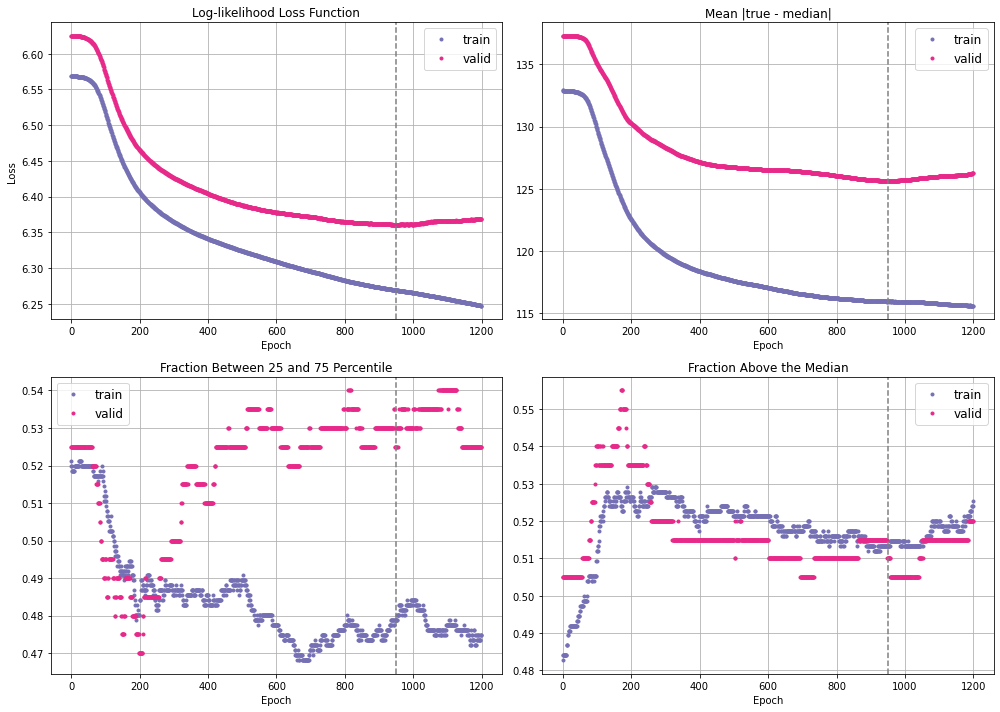

'longitude504_EPCP96_2015_shash2_network_seed_345_rng_seed_345'
Restoring model weights from the end of the best epoch: 1118.
Epoch 01368: early stopping
{'best_epoch': 1117,
 'elapsed_time': 18.68498206138611,
 'loss_train': 6.338347911834717,
 'loss_valid': 6.461950302124023,
 'network_seed': 345}


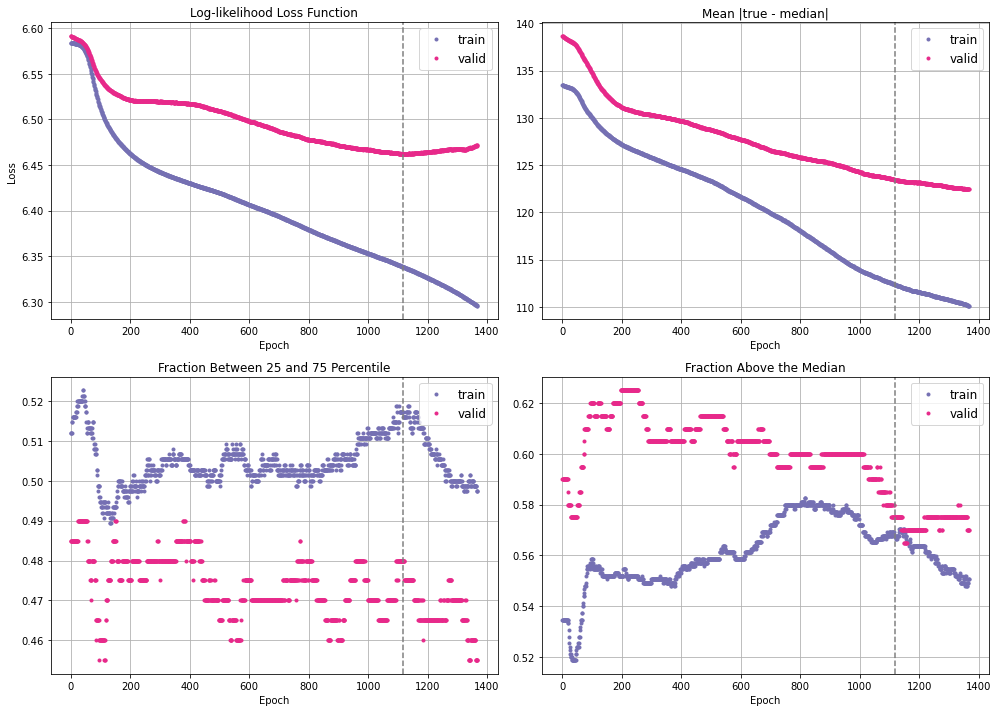

'longitude504_EPCP96_2016_shash2_network_seed_123_rng_seed_123'
Restoring model weights from the end of the best epoch: 872.
Epoch 01122: early stopping
{'best_epoch': 871,
 'elapsed_time': 16.78734803199768,
 'loss_train': 6.3562469482421875,
 'loss_valid': 6.444935321807861,
 'network_seed': 123}


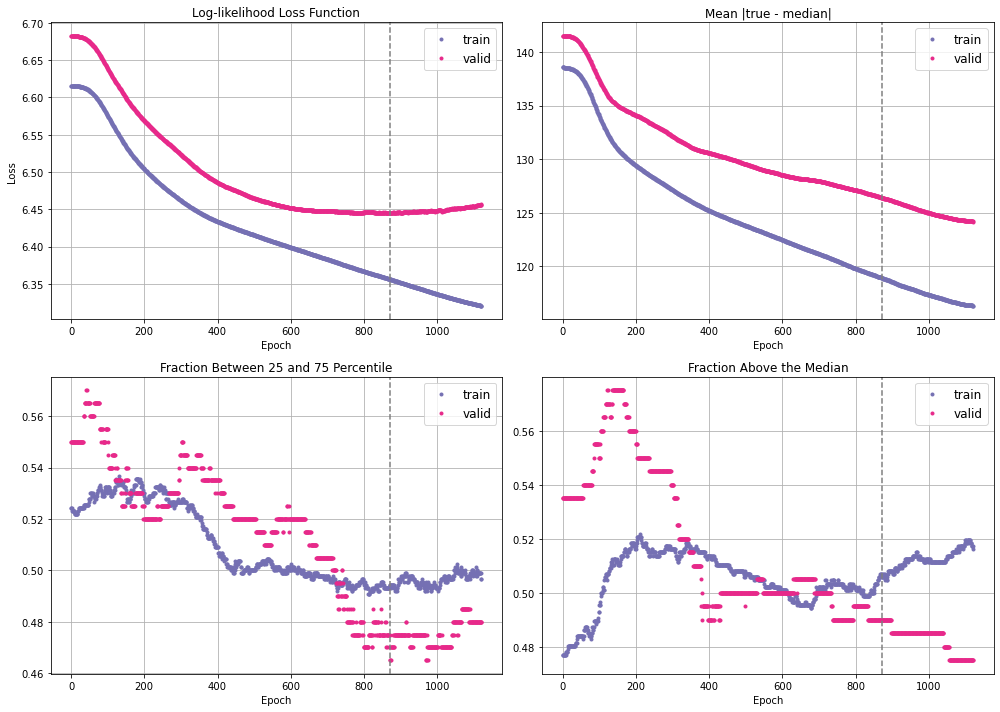

'longitude504_EPCP96_2016_shash2_network_seed_234_rng_seed_234'


In [ ]:
imp.reload(build_model)

for exp_name in EXP_NAME_LIST:
    settings = experiment_settings.get_settings(exp_name)

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013,2022)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementError('no such testing condition')
        
    for testing_years in TESTING_YEARS_LIST:        
        # set testing year
        settings["years_test"] = (testing_years,)
        
        
        for rng_seed in settings['rng_seed_list']:
            settings['rng_seed'] = rng_seed

            # build the intensity data tensors
            (
                data_summary,        
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,        
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

            # define the callbacks
            earlystoping_callback = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=settings["patience"],
                restore_best_weights=True,
                verbose=1,
            )

            training_callback = TrainingInstrumentation(
                x_train,
                onehot_train,
                interval=50,
            )

            callbacks = [earlystoping_callback, 
                         # training_callback,
                        ]

            # set network seed and train the model
            NETWORK_SEED_LIST = [settings["rng_seed"]]

            for network_seed in NETWORK_SEED_LIST:
                
                # set random seeds
                np.random.seed(rng_seed)
                random.seed(rng_seed)                            
                tf.random.set_seed(network_seed) 

                # Create the model name.
                model_name = (
                    exp_name + "_" + 
                    str(testing_years) + '_' +
                    settings["uncertainty_type"] + '_' + 
                    f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
                )

                # Make, compile, and train the model
                tf.keras.backend.clear_session()            
                model = build_model.make_model(
                    settings,
                    x_train,
                    onehot_train,
                    model_compile=True,
                )   
                # model.summary()

                # check if the model exists
                model_savename = MODEL_PATH + model_name + "_weights.h5"
                if os.path.exists(model_savename) and OVERWRITE_MODEL==False:
                    # print(model_savename + 'exists. Skipping...')
                    continue

                # train the network
                pprint.pprint(model_name)
                start_time = time.time()
                history = model.fit(
                    x_train,
                    onehot_train,
                    validation_data=(x_val, onehot_val),
                    batch_size=settings["batch_size"],
                    epochs=settings["n_epochs"],
                    shuffle=True,
                    verbose=0,
                    callbacks=callbacks,
                )
                stop_time = time.time()

                # Display the results, and save the model rum.
                best_epoch = np.argmin(history.history["val_loss"])
                fit_summary = {
                    "network_seed": network_seed,
                    "elapsed_time": stop_time - start_time,
                    "best_epoch": best_epoch,
                    "loss_train": history.history["loss"][best_epoch],
                    "loss_valid": history.history["val_loss"][best_epoch],
                }
                pprint.pprint(fit_summary, width=80)
                plot_history(history, model_name)

                save_model_run(
                    data_summary,
                    fit_summary,
                    model,
                    MODEL_PATH,
                    model_name,
                    settings,
                    __version__,
                )

In [ ]:
2+2